In [ ]:
import sys
import os
import importlib
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
src_path = os.path.abspath(os.path.join('..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

import src.preprocessing_data.pre_processing as pre_processing_module
import src.feature_engineering.build_features as build_features_module
import src.models.train_model as train_model_module
import src.visualization.visualize as visualize_module

importlib.reload(pre_processing_module)
importlib.reload(build_features_module)
importlib.reload(train_model_module)
importlib.reload(visualize_module)

from src.preprocessing_data.pre_processing import PreProcessor
from src.feature_engineering.build_features import LogisticRegressionFeatureEngineering
from src.models.train_model import BasicLogisticRegressionTraining
from src.visualization.visualize import LogisticRegressionVisualizer

In [ ]:
NROWS = 100000

processor = PreProcessor("../src/data/raw/balanced_10m_reviews.csv")
df = processor.preprocess(nrows=NROWS)

-------------------------
Current Dataframe has 100,000 rows and 20 columns.
No missing values found.

70,211 reviews are positive (70.2%) and 29,789 are negative (29.8%).

On average, authors have played for 13,936 minutes (median: 1,844, longest: 1,613,274).
At the time of writing, authors had played for 6,920 minutes on average (median: 829, longest: 1,280,710).

Reviews are 57.0 words long on average (median: 19, longest: 1,882 words).

Authors have written 35.9 reviews on average (median: 8, most prolific: 10,434).
Authors own 173.5 games on average (median: 0, most: 30,409).

Of the reviews in this dataframe:
  65,814 (65.8%) were purchased on Steam.
  3,554 (3.6%) were received for free.
  12,785 (12.8%) were written during early access.

The current dataframe covers 11,729 unique game(s).
-------------------------


In [ ]:
base_builder = LogisticRegressionFeatureEngineering(df)
base_train_df, base_test_df = base_builder.split_data()

print(f"Training set: {len(base_train_df):,} rows")
print(f"Test set:     {len(base_test_df):,} rows")
print(f"Features:     {base_builder.feature_cols}")

Training set: 80,000 rows
Test set:     20,000 rows
Features:     ['author_steamid', 'author_num_games_owned', 'author_num_reviews', 'author_playtime_forever', 'author_playtime_last_two_weeks', 'author_playtime_at_review', 'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access']


In [ ]:
feature_builder = LogisticRegressionFeatureEngineering(df)

feature_builder.votes_ratio()
feature_builder.playtime_ratio()
feature_builder.review_length()

train_df, test_df = feature_builder.split_data()

print(f"Training set: {len(train_df):,} rows")
print(f"Test set:     {len(test_df):,} rows")
print(f"Features:     {feature_builder.feature_cols}")

Training set: 80,000 rows
Test set:     20,000 rows
Features:     ['author_steamid', 'author_num_games_owned', 'author_num_reviews', 'author_playtime_forever', 'author_playtime_last_two_weeks', 'author_playtime_at_review', 'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'votes_ratio', 'playtime_ratio', 'review_length']


In [ ]:
lr_trainer = BasicLogisticRegressionTraining(train_df, test_df, feature_builder)
lr_trainer.set_features()
lr_trainer.train()

baseline_results = lr_trainer.evaluate()

print("\nBaseline LR Results:")
for k, v in baseline_results.items():
    print(f"  {k}: {v}")


Baseline LR Results:
  accuracy: 0.70865
  precision: 0.8385395203164923
  recall: 0.7245406637231163
  f1_score: 0.7773829990448902
  confusion_matrix: [[ 3999  1959]
 [ 3868 10174]]


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

param_grid = {
    "C":        [0.01, 0.1, 1, 10, 100],
    "solver":   ["newton-cg", "lbfgs", "saga"],
    "max_iter": [500, 1000]
}

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[feature_builder.feature_cols])
y_train = train_df[feature_builder.target_col]

grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced"),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-val F1: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters: {'C': 10, 'max_iter': 500, 'solver': 'saga'}
Best cross-val F1: 0.7727


In [ ]:


X_test_scaled = scaler.transform(test_df[feature_builder.feature_cols])
y_test = test_df[feature_builder.target_col]

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print("Tuned LR Results:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred):.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

Tuned LR Results:
  Accuracy:  0.7087
  Precision: 0.8386
  Recall:    0.7246
  F1:        0.7774
  Confusion Matrix:
[[ 3999  1959]
 [ 3867 10175]]


In [ ]:


metrics = ["accuracy", "precision", "recall", "f1_score"]
comparison = pd.DataFrame({
    "Baseline": [baseline_results[m] for m in metrics],
    "Tuned":    [accuracy_score(y_test, y_pred),
                 precision_score(y_test, y_pred),
                 recall_score(y_test, y_pred),
                 f1_score(y_test, y_pred)]
}, index=metrics)

print(comparison.round(4))

           Baseline   Tuned
accuracy     0.7086  0.7087
precision    0.8385  0.8386
recall       0.7245  0.7246
f1_score     0.7774  0.7774


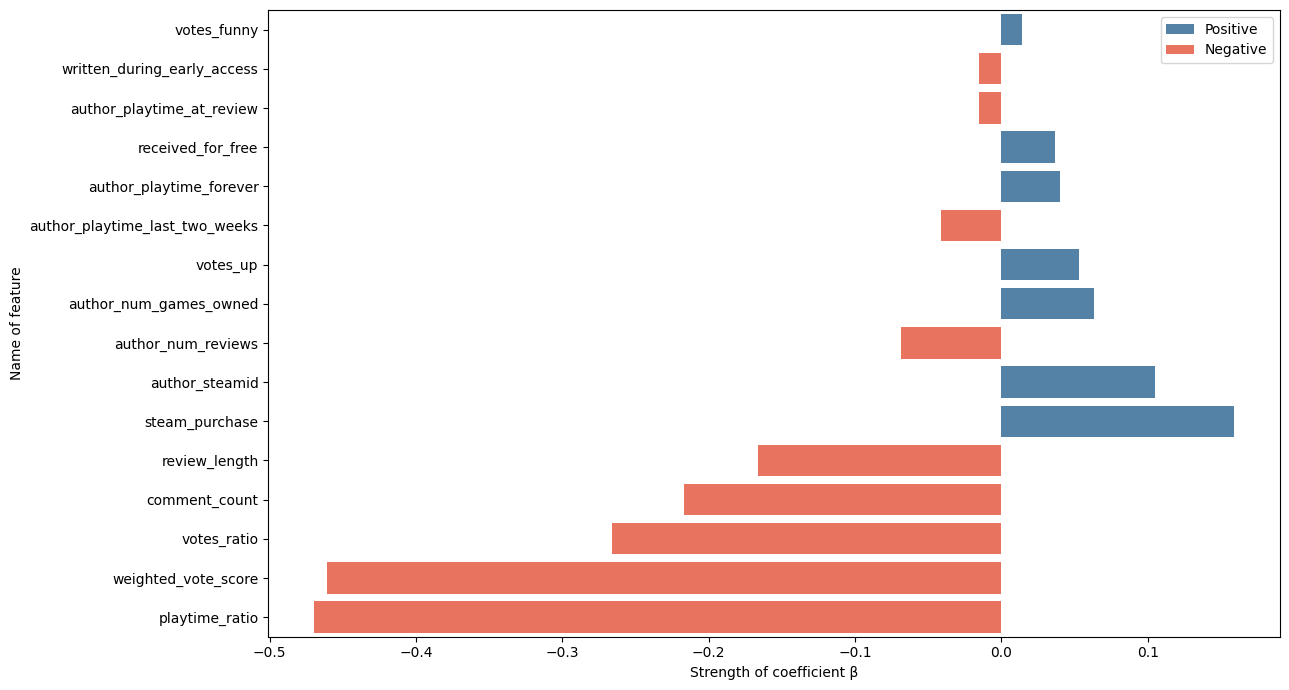

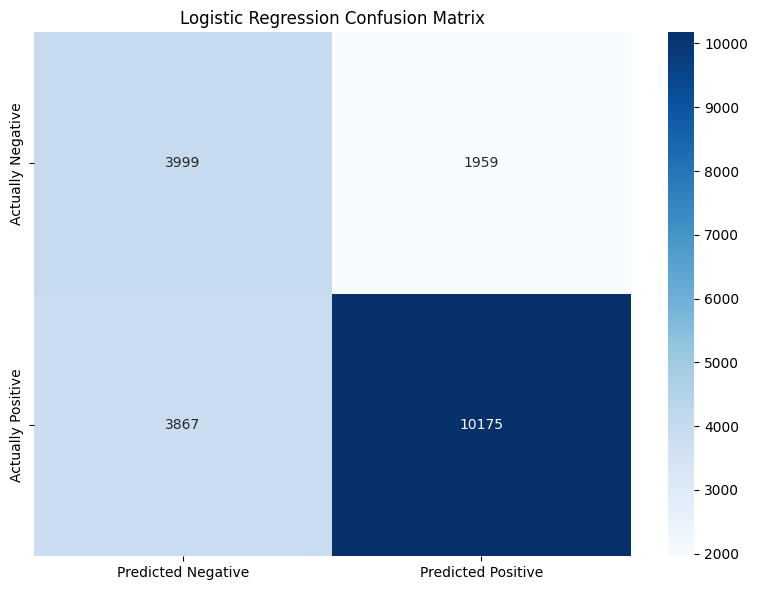

In [ ]:
lr_plot = LogisticRegressionVisualizer(best_model, feature_builder.feature_cols)
lr_plot.plot_all(y_test, y_pred)

In [ ]:
joblib.dump(best_model, "../src/models/logistic_model_tuned.pkl")
joblib.dump(scaler, "../src/models/scaler_tuned.pkl")
print(f"Best model saved. Params: {grid_search.best_params_}")

Saved best model with params: {'C': 10, 'max_iter': 500, 'solver': 'saga'}
